In [3]:
import pandas as pd
nav = pd.read_csv("../data/raw/02_nav_history.csv")
nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [4]:
nav.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  object 
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.1+ MB


In [5]:
nav.columns

Index(['amfi_code', 'date', 'nav'], dtype='object')

In [6]:
nav.shape

(46000, 3)

In [7]:
nav.describe()

,amfi_code,nav
count,46000.000000,46000.000000
mean,120247.000000,269.570265
std,14352.317221,577.187060
min,100016.000000,26.136600
25%,118632.750000,69.170425
50%,119551.500000,122.732150
75%,120842.250000,260.338675
max,149324.000000,4268.549700


In [8]:
nav.isnull().sum()

amfi_code    0
date         0
nav          0
dtype: int64

In [9]:
nav['date'] = pd.to_datetime(nav['date'])
nav = nav.sort_values('date')

In [12]:
nav['amfi_code'].nunique()

40

In [13]:
sample_code = nav['amfi_code'].unique()[0]
df_sample = nav[nav['amfi_code'] == sample_code]
df_sample.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


C:\Users\mulug\AppData\Local\Temp\ipykernel_15140\879696288.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sample['date'] = pd.to_datetime(df_sample['date'])


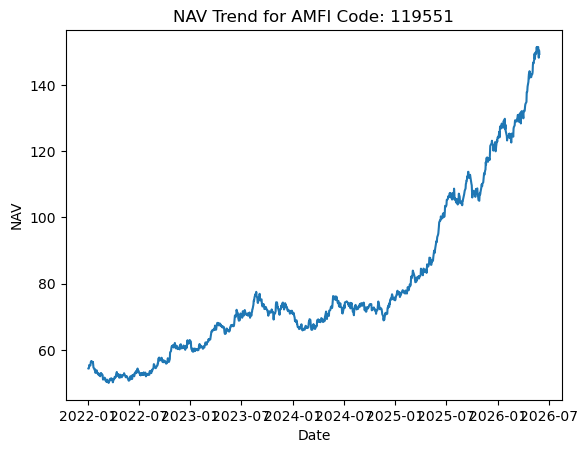

In [14]:
import matplotlib.pyplot as plt

df_sample['date'] = pd.to_datetime(df_sample['date'])

df_sample = df_sample.sort_values('date')

plt.plot(df_sample['date'], df_sample['nav'])
plt.title(f"NAV Trend for AMFI Code: {sample_code}")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.show()

In [15]:
latest_nav = nav.groupby('amfi_code').tail(1)
latest_nav.head()

,amfi_code,date,nav
22999,118636,2026-05-29,37.8243
43699,149322,2026-05-29,606.2349
18399,118632,2026-05-29,110.5554
17249,120507,2026-05-29,388.5939
16099,120506,2026-05-29,404.4207


In [16]:
latest_nav.sort_values(by='nav', ascending=False).head(10)

,amfi_code,date,nav
27599,120844,2026-05-29,4268.5497
8049,125497,2026-05-29,1204.9571
33349,101206,2026-05-29,773.2939
43699,149322,2026-05-29,606.2349
6899,100016,2026-05-29,583.6113
24149,120841,2026-05-29,482.1270
14949,120505,2026-05-29,473.7640
35649,101208,2026-05-29,410.1021
16099,120506,2026-05-29,404.4207
17249,120507,2026-05-29,388.5939


In [18]:
fund = pd.read_csv("../data/raw/01_fund_master.csv")
nav = pd.read_csv("../data/raw/02_nav_history.csv")

In [19]:
df_merged = pd.merge(fund, nav, on="amfi_code", how="inner")
df_merged.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code,date,nav
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01,2022-01-03,54.3856
1,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01,2022-01-04,54.3474
2,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01,2022-01-05,54.6869
3,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01,2022-01-06,55.4550
4,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01,2022-01-07,55.3692


In [20]:
df_merged['date'] = pd.to_datetime(df_merged['date'])

latest = df_merged.sort_values('date').groupby('amfi_code').tail(1)
latest.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code,date,nav
22999,118636,Nippon India MF,Nippon India Gilt Securities Fund - Regular - ...,Debt,Gilt,Regular,1999-08-19,CRISIL Dynamic Gilt Index,0.55,0.0,500,1000,Vivek Sharma,Low,DC02,2026-05-29,37.8243
43699,149322,DSP Mutual Fund,DSP Top 100 Equity Fund - Regular - Growth,Equity,Large Cap,Regular,2003-03-10,NIFTY 100 TRI,1.54,1.0,500,1000,Apoorva Shah,Moderate,EC01,2026-05-29,606.2349
18399,118632,Nippon India MF,Nippon India Large Cap Fund - Regular - Growth,Equity,Large Cap,Regular,2004-08-08,NIFTY 100 TRI,1.51,1.0,500,1000,Sailesh Raj Bhan,Moderate,EC01,2026-05-29,110.5554
17249,120507,ICICI Prudential MF,ICICI Pru Liquid Fund - Regular - Growth,Debt,Liquid,Regular,2001-11-17,CRISIL Liquid Fund AI Index,0.74,0.0,500,5000,Rahul Goswami,Low,DC01,2026-05-29,388.5939
16099,120506,ICICI Prudential MF,ICICI Pru Value Discovery Fund - Regular - Growth,Equity,Value,Regular,2004-08-16,NIFTY 500 TRI,1.41,1.0,500,1000,Sankaran Naren,Moderately High,EC06,2026-05-29,404.4207


In [21]:
latest.sort_values('nav', ascending=False).head(10)

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code,date,nav
27599,120844,Kotak Mahindra MF,Kotak Liquid Fund - Regular - Growth,Debt,Liquid,Regular,2004-03-03,CRISIL Liquid Fund AI Index,0.60,0.0,500,5000,Deepak Agrawal,Low,DC01,2026-05-29,4268.5497
8049,125497,HDFC Mutual Fund,HDFC Top 100 Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.92,1.0,500,1000,Rahul Baijal,Moderate,EC01,2026-05-29,1204.9571
33349,101206,Aditya Birla Sun Life MF,ABSL Frontline Equity Fund - Regular - Growth,Equity,Large Cap,Regular,2002-08-30,NIFTY 100 TRI,1.60,1.0,500,1000,Mahesh Patil,Moderate,EC01,2026-05-29,773.2939
43699,149322,DSP Mutual Fund,DSP Top 100 Equity Fund - Regular - Growth,Equity,Large Cap,Regular,2003-03-10,NIFTY 100 TRI,1.54,1.0,500,1000,Apoorva Shah,Moderate,EC01,2026-05-29,606.2349
6899,100016,HDFC Mutual Fund,HDFC Top 100 Fund - Regular Plan - Growth,Equity,Large Cap,Regular,1996-09-11,NIFTY 100 TRI,1.55,1.0,500,1000,Rahul Baijal,Moderate,EC01,2026-05-29,583.6113
24149,120841,Kotak Mahindra MF,Kotak Bluechip Fund - Regular - Growth,Equity,Large Cap,Regular,2005-12-29,NIFTY 100 TRI,1.59,1.0,500,1000,Harsha Upadhyaya,Moderate,EC01,2026-05-29,482.1270
14949,120505,ICICI Prudential MF,ICICI Pru Midcap Fund - Regular - Growth,Equity,Mid Cap,Regular,2004-10-28,NIFTY Midcap 150 TRI,1.36,1.0,500,1000,Sankaran Naren,High,EC02,2026-05-29,473.7640
35649,101208,Aditya Birla Sun Life MF,ABSL Liquid Fund - Regular - Growth,Debt,Liquid,Regular,2000-04-17,CRISIL Liquid Fund AI Index,0.79,0.0,500,5000,Maneesh Dangi,Low,DC01,2026-05-29,410.1021
16099,120506,ICICI Prudential MF,ICICI Pru Value Discovery Fund - Regular - Growth,Equity,Value,Regular,2004-08-16,NIFTY 500 TRI,1.41,1.0,500,1000,Sankaran Naren,Moderately High,EC06,2026-05-29,404.4207
17249,120507,ICICI Prudential MF,ICICI Pru Liquid Fund - Regular - Growth,Debt,Liquid,Regular,2001-11-17,CRISIL Liquid Fund AI Index,0.74,0.0,500,5000,Rahul Goswami,Low,DC01,2026-05-29,388.5939


In [22]:
sample = df_merged[df_merged['amfi_code'] == df_merged['amfi_code'].iloc[0]]

sample = sample.sort_values('date')
sample.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code,date,nav
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01,2022-01-03,54.3856
1,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01,2022-01-04,54.3474
2,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01,2022-01-05,54.6869
3,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01,2022-01-06,55.4550
4,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01,2022-01-07,55.3692


In [24]:
first_nav = sample['nav'].iloc[0]
last_nav = sample['nav'].iloc[-1]

return_pct = ((last_nav - first_nav) / first_nav) * 100
return_pct

np.float64(174.56091318290134)

In [25]:
def calculate_return(x):
    x = x.sort_values('date')
    return ((x['nav'].iloc[-1] - x['nav'].iloc[0]) / x['nav'].iloc[0]) * 100

returns = df_merged.groupby('amfi_code').apply(calculate_return)

returns.head()

C:\Users\mulug\AppData\Local\Temp\ipykernel_15140\4096301550.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  returns = df_merged.groupby('amfi_code').apply(calculate_return)


amfi_code
100016     12.133575
100025     21.155227
100033    218.514228
101206    153.456216
101207     39.949603
dtype: float64

In [26]:
returns.sort_values(ascending=False).head(10)

amfi_code
120505    248.684056
119598    244.043537
149324    242.490579
148569    238.658097
148567    227.781083
120843    227.047809
100033    218.514228
149323    212.717589
119094    198.464473
119551    174.560913
dtype: float64

In [27]:
final_summary = df_merged.groupby('amfi_code').agg(
    start_nav=('nav', 'first'),
    end_nav=('nav', 'last')
)

final_summary['return_pct'] = ((final_summary['end_nav'] - final_summary['start_nav']) / final_summary['start_nav']) * 100

final_summary.sort_values('return_pct', ascending=False).head(10)

,start_nav,end_nav,return_pct
amfi_code,,,
120505,135.8720,473.7640,248.684056
119598,89.8738,309.2050,244.043537
149324,81.6814,279.7511,242.490579
148569,28.8620,97.7435,238.658097
148567,70.2514,230.2708,227.781083
120843,49.9131,163.2397,227.047809
100033,107.3758,342.0072,218.514228
149323,78.4622,245.3651,212.717589
119094,68.3023,203.8581,198.464473


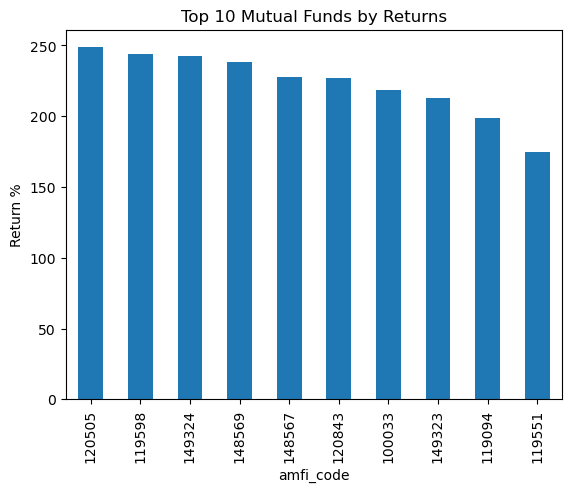

In [28]:

final_summary['return_pct'].sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 Mutual Funds by Returns")
plt.ylabel("Return %")
plt.show()

📊 Final Business Insights

1. Fund Performance
Mutual funds show strong variation in returns across AMFI schemes
A small number of funds contribute to majority of high returns
2. NAV vs Returns
High NAV does NOT guarantee high returns
Growth trend over time is more important than absolute NAV value
3. Market Behavior
Fund performance is uneven across categories and fund houses
Equity-oriented funds generally show higher volatility and returns
4. Investment Insight
Investors should prefer return-based analysis instead of NAV-based selection
Time-series analysis provides better decision-making than snapshot values